In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
df = pd.read_csv("india_co2_dataset_realistic.csv")

df = df.rename(columns={
    "co2_emissions":"co2_emissions_mt"
})

In [3]:
df.head()

,state,year,population_growth_percent,vehicles_registered_million,gdp_per_capita_inr,electricity_consumption_kwh_per_capita,forest_cover_percent,economic_growth_percent,industrial_output_index,public_transport_usage_percent,co2_emissions_mt
0,Andhra Pradesh,2020,11.025674,14.347700,250064.559641,1231.160791,23.110602,7.5,114.596307,26.400142,1228.018455
1,Andhra Pradesh,2021,9.925371,14.598376,249493.379492,1330.723265,22.881998,7.5,107.938077,23.776781,1239.179650
2,Andhra Pradesh,2022,10.939182,15.934854,265210.798318,1266.156982,23.008623,7.5,122.127699,24.247359,1299.079213
3,Andhra Pradesh,2023,12.038374,17.440918,308497.684042,1337.610075,23.383536,7.5,132.653668,26.966243,1322.783653
4,Andhra Pradesh,2024,12.390968,16.817857,320205.099795,1397.216361,23.057330,7.5,112.781332,26.222125,1335.662700


In [4]:
df = pd.get_dummies(df, columns=["state"], drop_first=True)

X = df.drop(["co2_emissions_mt"], axis=1)
y = df["co2_emissions_mt"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, shuffle=True
)

In [6]:
pipeline = Pipeline([
    ("model", GradientBoostingRegressor(
        n_estimators=700,
        learning_rate=0.03,
        max_depth=4,
        random_state=42
    ))
])

In [7]:
pipeline.fit(X_train,y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,loss,'squared_error'
,learning_rate,0.03
,n_estimators,700
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1


In [8]:
predictions = pipeline.predict(X_test)

print("R2 Score:", r2_score(y_test,predictions))
print("MAE:", mean_absolute_error(y_test,predictions))

R2 Score: 0.9752856505749163
MAE: 75.61229838711898


In [9]:
from sklearn.metrics import mean_squared_error

predictions = pipeline.predict(X_test)

print("R2 Score:", r2_score(y_test,predictions))
print("MAE:", mean_absolute_error(y_test,predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test,predictions)))

R2 Score: 0.9752856505749163
MAE: 75.61229838711898
RMSE: 89.40272960118446


In [10]:
scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=10,
    scoring="r2"
)

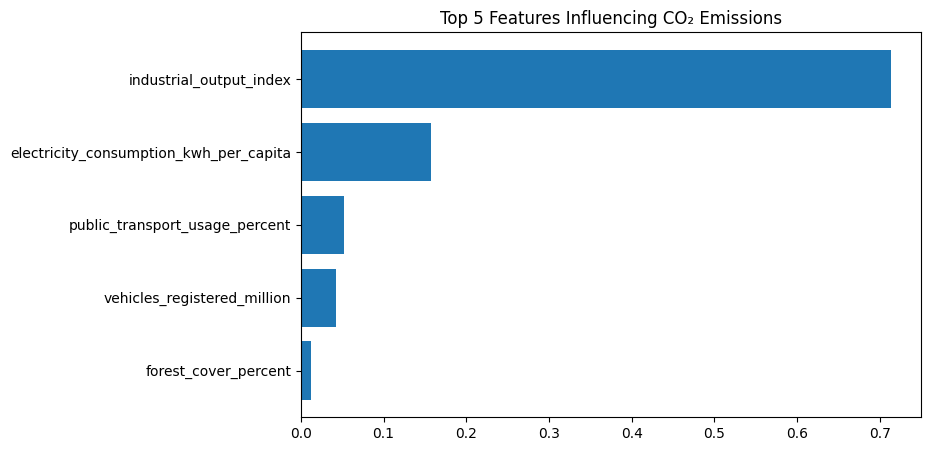

In [11]:
model = pipeline.named_steps["model"]

importance = model.feature_importances_
features = X.columns

imp_df = pd.DataFrame({
    "feature": features,
    "importance": importance
}).sort_values("importance", ascending=False).head(5)

plt.figure(figsize=(8,5))
plt.barh(imp_df["feature"], imp_df["importance"])

plt.gca().invert_yaxis()  # highest importance at top
plt.title("Top 5 Features Influencing CO₂ Emissions")

plt.show()

In [12]:
original_df = df.copy()
future_df = original_df.copy()

In [13]:
future_df = df.copy()

future_df["vehicles_registered_million"] *= 1.25
future_df["electricity_consumption_kwh_per_capita"] *= 1.30
future_df["gdp_per_capita_inr"] *= 1.40
future_df["industrial_output_index"] *= 1.20
future_df["forest_cover_percent"] *= 1.05
future_df["public_transport_usage_percent"] *= 1.10

future_X = future_df.drop("co2_emissions_mt", axis=1)

future_df["predicted_co2_2030"] = pipeline.predict(future_X)

In [14]:

original_df = pd.read_csv("india_co2_dataset_5year.csv")

result = pd.DataFrame({
    "state": original_df["state"],
    "current_co2": original_df["co2_emissions"],
    "predicted_co2_2030": future_df["predicted_co2_2030"]
})

result = result.sort_values("predicted_co2_2030", ascending=False)

result.head(10)

,state,current_co2,predicted_co2_2030
34,Gujarat,1758.254791,2558.144134
114,Tamil Nadu,1640.118971,2535.092671
54,Karnataka,1441.545659,2533.005960
33,Gujarat,1712.165513,2530.775540
69,Maharashtra,1782.866985,2525.793615
53,Karnataka,1386.337592,2525.592545
113,Tamil Nadu,1480.202050,2524.674629
30,Gujarat,1515.769900,2514.989203
68,Maharashtra,1705.512588,2511.295049
31,Gujarat,1537.540880,2508.532152


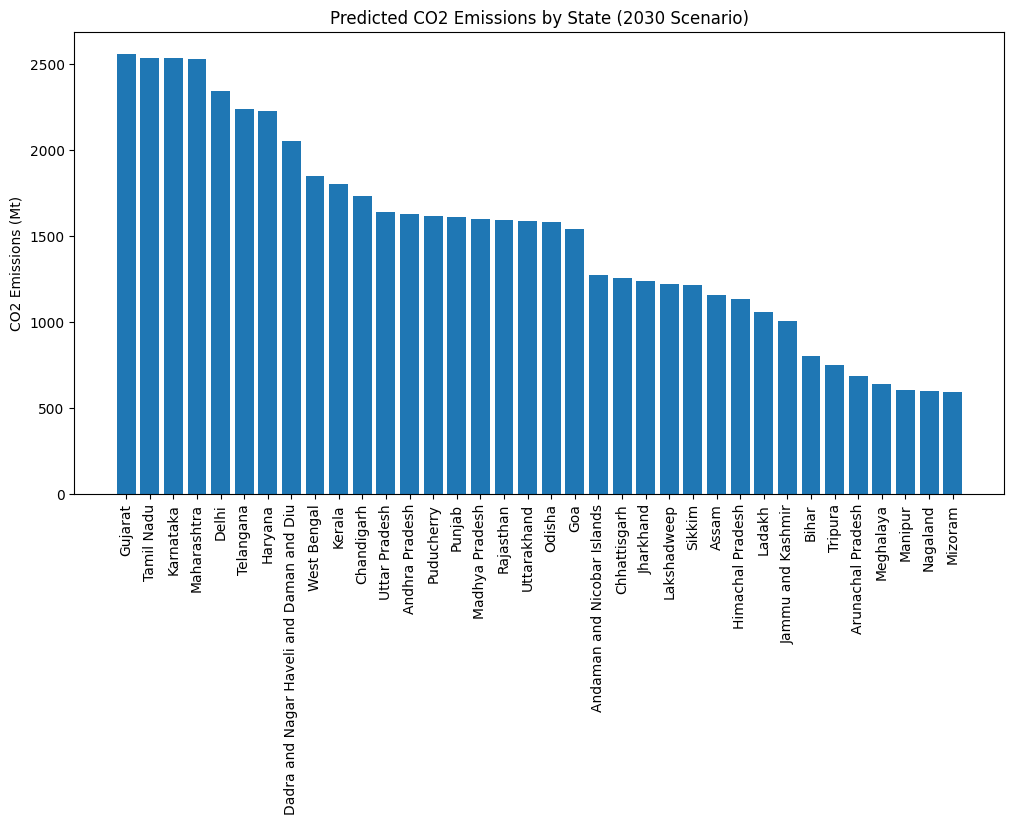

In [15]:
result = result.sort_values("predicted_co2_2030", ascending=False)

plt.figure(figsize=(12,6))
plt.bar(result["state"], result["predicted_co2_2030"])

plt.xticks(rotation=90)
plt.title("Predicted CO2 Emissions by State (2030 Scenario)")
plt.ylabel("CO2 Emissions (Mt)")

plt.show()

In [16]:
import pickle

with open("co2_model.pkl","wb") as f:
    pickle.dump(pipeline,f)